# CNN-LSTM Classification pour la cohérence cardiaque

## Notebook d'entraînement et classification basé sur CNN-LSTM

Ce notebook implémente un modèle CNN-LSTM pour la classification de séquences temporelles de fréquence cardiaque. Ceci vise à architecturer un modèle de réseau de neurones convutionnel couplé à un LSTM (Long short-term memory) pour la classification de la cybersickness.


In [1]:
# import bibliothèques data/entraînement modèle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Configuration DirectML pour Windows GPU support
print("Configuration GPU/DirectML...")
gpus = tf.config.list_physical_devices('GPU')
if len(gpus) > 0:
    print(f"✓ {len(gpus)} GPU(s) détecté(s):")
    for gpu in gpus:
        print(f"  - {gpu}")
        # Allocation dynamique de mémoire
        tf.config.experimental.set_memory_growth(gpu, True)
else:
    print("Aucun GPU détecté - utilisation du CPU")

# Affichage
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)

Configuration GPU/DirectML...
✓ 1 GPU(s) détecté(s):
  - PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


# Données RR Intervals - Cohérence Cardiaque

## Description

Ce notebook charge et analyse les données de RRintervalsClean.mat (intervalles entre battements cardiaques) depuis un fichier MATLAB.

In [2]:
# Récupération et visualisation des données
import os
import scipy.io

mat_file_path = r"../data/Données Cohérence Cardiaque/RRintervalsClean.mat"
rr_entries = []
rr_table = None

if os.path.exists(mat_file_path):
    print(f"Fichier trouvé: {mat_file_path}\n")
    data = scipy.io.loadmat(mat_file_path)

    print(f"\nClés disponibles: {list(data.keys())}\n")

    def extract_numeric_series(value):
        series_list = []
        array_value = np.asarray(value, dtype=object)

        if array_value.dtype != object:
            numeric = np.asarray(array_value, dtype=float).squeeze()
            if numeric.ndim == 1 and numeric.size > 0:
                series_list.append(numeric)
            elif numeric.ndim > 1:
                for row in numeric:
                    row_array = np.asarray(row, dtype=float).squeeze()
                    if row_array.ndim == 1 and row_array.size > 0:
                        series_list.append(row_array)
            return series_list

        for item in array_value.flat:
            item_array = np.asarray(item).squeeze()
            if item_array.size == 0:
                continue
            try:
                numeric = np.asarray(item_array, dtype=float).reshape(-1)
            except (TypeError, ValueError):
                continue
            if numeric.size > 0:
                series_list.append(numeric)
        return series_list

    for key, value in data.items():
        if key.startswith('__'):
            continue

        print(f"Variable: '{key}'")
        print(f"  Type brut: {type(value)}")
        print(f"  Shape brute: {np.asarray(value).shape}")
        print(f"  Dtype brut: {np.asarray(value).dtype}")

        extracted = extract_numeric_series(value)
        print(f"  Séries numériques extraites: {len(extracted)}")

        if extracted:
            lengths = [len(series) for series in extracted]
            print(f"  Longueur min/max: {min(lengths)} / {max(lengths)}")
            print(f"  Exemple 10 premières valeurs: {extracted[0][:10]}")

            for index, series in enumerate(extracted, start=1):
                rr_entries.append({
                    'variable': key,
                    'serie_id': f"{key}_{index}",
                    'length': len(series),
                    'mean': float(np.mean(series)),
                    'std': float(np.std(series)),
                    'min': float(np.min(series)),
                    'max': float(np.max(series)),
                    'values': series,
                })
        print()

    print("=" * 60)
    print("DONNÉES NUMÉRIQUES")
    print("=" * 60)

    if rr_entries:
        rr_table = pd.DataFrame([
            {
                'serie_id': entry['serie_id'],
                'length': entry['length'],
                'mean': entry['mean'],
                'std': entry['std'],
                'min': entry['min'],
                'max': entry['max'],
            }
            for entry in rr_entries
        ])

        print("Résumé des séries extraites:")
        display(rr_table.head(20))

        preview_df = pd.DataFrame({
            entry['serie_id']: pd.Series(entry['values'][:20])
            for entry in rr_entries[:5]
        })
        print("\nAperçu numérique des 5 premières séries (20 premières valeurs):")
        display(preview_df)
    else:
        print("Aucune série numérique exploitable n'a été trouvée.")
else:
    print(f"Fichier non trouvé: {mat_file_path}")
    print("\nAssurez-vous que le chemin est correct et que le fichier existe.")
    print("Répertoires disponibles:")
    if os.path.exists('data'):
        for root, dirs, files in os.walk('data'):
            level = root.replace('data', '').count(os.sep)
            indent = ' ' * 2 * level
            print(f"{indent}{os.path.basename(root)}/")
            subindent = ' ' * 2 * (level + 1)
            for file in files:
                print(f"{subindent}{file}")

Fichier trouvé: ../data/Données Cohérence Cardiaque/RRintervalsClean.mat


Clés disponibles: ['__header__', '__version__', '__globals__', 'RRintervalsClean', '__function_workspace__']

Variable: 'RRintervalsClean'
  Type brut: <class 'numpy.ndarray'>
  Shape brute: (36, 10)
  Dtype brut: object
  Séries numériques extraites: 276
  Longueur min/max: 251 / 1928
  Exemple 10 premières valeurs: [681. 718. 727. 775. 812. 786. 842. 872. 777. 725.]

DONNÉES NUMÉRIQUES
Résumé des séries extraites:


,serie_id,length,mean,std,min,max
0,RRintervalsClean_1,397,764.528967,56.897205,620.0,897.0
1,RRintervalsClean_2,396,756.161616,77.209339,603.0,966.0
2,RRintervalsClean_3,1580,761.662658,65.278833,587.0,983.0
3,RRintervalsClean_4,402,747.226368,72.629373,612.0,1011.0
4,RRintervalsClean_5,487,629.915811,38.534966,530.0,756.0
5,RRintervalsClean_6,463,667.665227,32.333010,568.0,759.0
6,RRintervalsClean_7,440,687.702273,69.444811,555.0,859.0
7,RRintervalsClean_8,398,783.643216,85.231481,532.0,984.0
8,RRintervalsClean_9,408,743.620098,40.488019,611.0,867.0
9,RRintervalsClean_10,1497,820.788243,70.681225,357.0,1201.0



Aperçu numérique des 5 premières séries (20 premières valeurs):


,RRintervalsClean_1,RRintervalsClean_2,RRintervalsClean_3,RRintervalsClean_4,RRintervalsClean_5
0,681.0,712.0,789.0,678.0,587.0
1,718.0,751.0,801.0,694.0,593.0
2,727.0,834.0,787.0,728.0,586.0
3,775.0,859.0,796.0,767.0,578.0
4,812.0,853.0,793.0,790.0,554.0
5,786.0,832.0,781.0,827.0,535.0
6,842.0,789.0,751.0,838.0,532.0
7,872.0,727.0,772.0,858.0,530.0
8,777.0,668.0,784.0,885.0,530.0
9,725.0,643.0,789.0,875.0,541.0


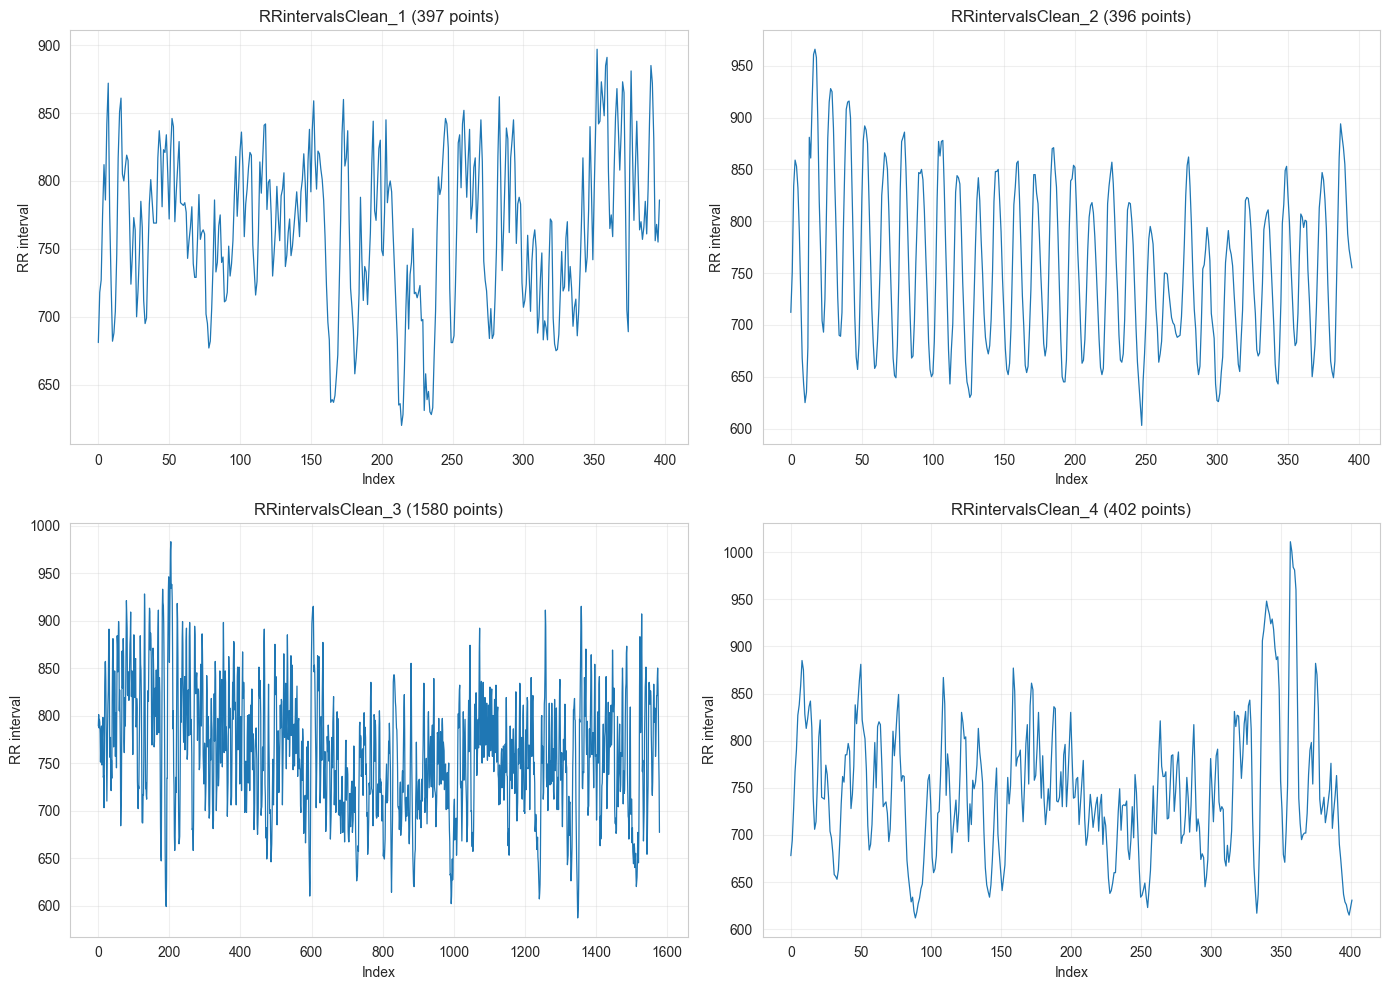

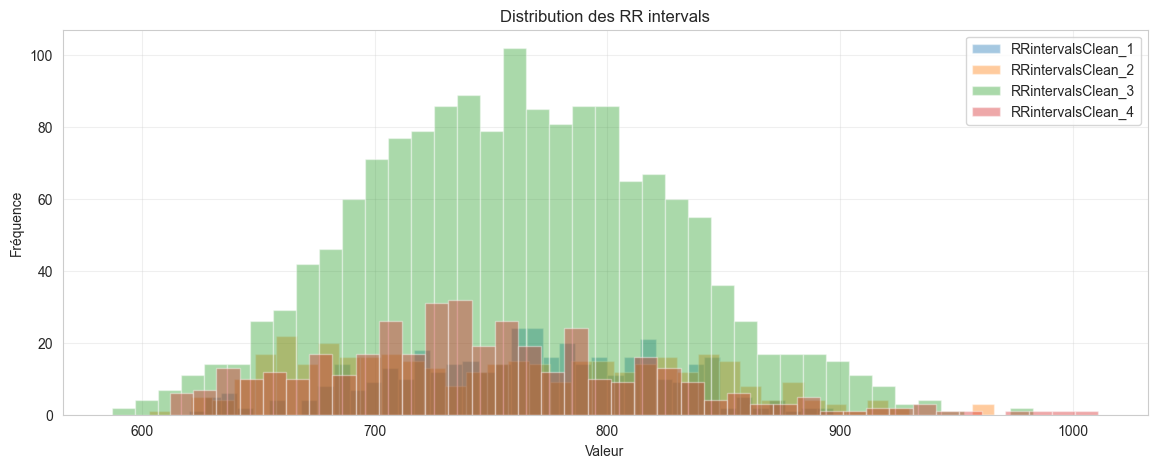


STATISTIQUES DESCRIPTIVES


,serie_id,length,mean,std,min,max
count,276,276.000000,276.000000,276.000000,276.000000,276.000000
unique,276,NaN,NaN,NaN,NaN,NaN
top,RRintervalsClean_1,NaN,NaN,NaN,NaN,NaN
freq,1,NaN,NaN,NaN,NaN,NaN
mean,NaN,507.793478,869.473905,96.724595,632.521739,1206.485507
std,NaN,356.667705,135.219460,41.290734,99.292165,315.057437
min,NaN,251.000000,563.757974,30.171361,321.000000,663.000000
25%,NaN,331.750000,764.157998,65.759400,576.500000,1044.000000
50%,NaN,377.000000,858.622992,89.825372,626.000000,1178.500000
75%,NaN,449.000000,953.388611,116.816355,689.250000,1323.000000


In [3]:
# Visualisation graphique des données RR intervals
if not rr_entries:
    raise ValueError("Aucune série RR exploitable n'est disponible. Exécutez d'abord la cellule de chargement.")

selected_entries = rr_entries[:4]
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for axis, entry in zip(axes, selected_entries):
    series = entry['values']
    axis.plot(series, linewidth=0.9)
    axis.set_title(f"{entry['serie_id']} ({entry['length']} points)")
    axis.set_xlabel('Index')
    axis.set_ylabel('RR interval')
    axis.grid(True, alpha=0.3)

for axis in axes[len(selected_entries):]:
    axis.axis('off')

plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 5))
for entry in selected_entries:
    plt.hist(entry['values'], bins=40, alpha=0.4, label=entry['serie_id'])
plt.title('Distribution des RR intervals')
plt.xlabel('Valeur')
plt.ylabel('Fréquence')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

stats_df = rr_table.copy() if rr_table is not None else pd.DataFrame()
if not stats_df.empty:
    print("\nSTATISTIQUES DESCRIPTIVES")
    display(stats_df.describe(include='all'))

Shape brute RRintervalsClean: (36, 10)
Classe 'repos' (colonne 6): 36 séries, 12449 fenêtres
Classe 'environnement_immersif' (colonne 7): 36 séries, 11420 fenêtres
Classe 'coherence_cardiaque_immersif' (colonne 8): 36 séries, 11262 fenêtres

Résumé dataset:
  X shape: (35131, 50, 1)
  y shape: (35131,)
  - repos: 12449 échantillons
  - environnement_immersif: 11420 échantillons
  - coherence_cardiaque_immersif: 11262 échantillons


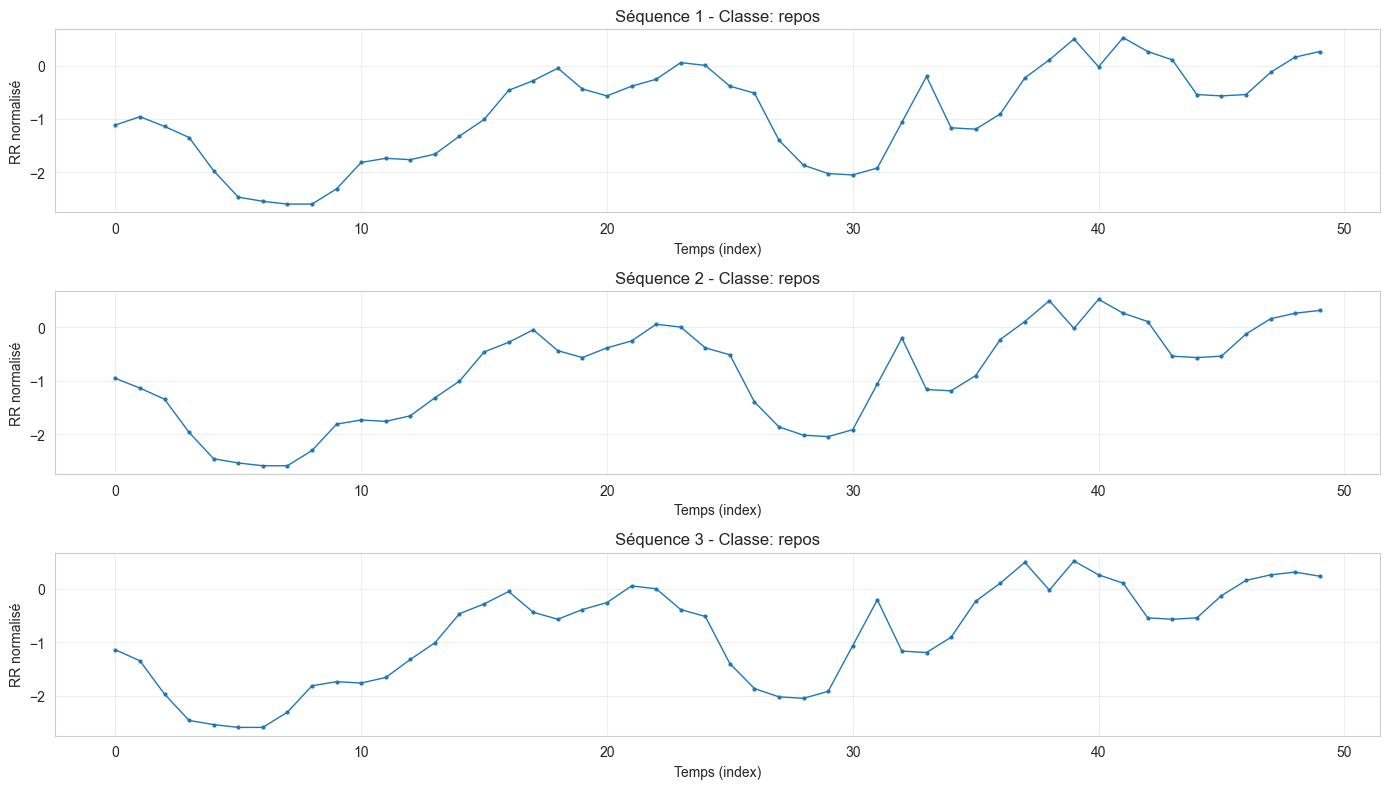

In [4]:
# Préparation des données pour le modèle CNN-LSTM
if 'data' not in locals() or 'RRintervalsClean' not in data:
    raise ValueError("Variable 'RRintervalsClean' introuvable. Exécutez d'abord la cellule de chargement.")

rr_matrix = np.asarray(data['RRintervalsClean'], dtype=object)
print(f"Shape brute RRintervalsClean: {rr_matrix.shape}")

# Colonnes MATLAB demandées: 6, 7, 8 -> indices Python 5, 6, 7
selected_columns = {
    5: 'repos',
    6: 'environnement_immersif',
    7: 'coherence_cardiaque_immersif'
}
class_names = ['repos', 'environnement_immersif', 'coherence_cardiaque_immersif']

SEQUENCE_LENGTH = 50
X_sequences = []
y_labels = []
source_info = []

for col_idx, class_name in selected_columns.items():
    if col_idx >= rr_matrix.shape[1]:
        print(f"Colonne {col_idx + 1} absente dans RRintervalsClean")
        continue

    class_id = class_names.index(class_name)
    valid_series = 0
    generated_windows = 0

    # Parcours des lignes (sessions/sujets)
    for row_idx in range(rr_matrix.shape[0]):
        cell_value = rr_matrix[row_idx, col_idx]
        series = np.asarray(cell_value).squeeze()

        if series.size == 0:
            continue

        try:
            series = np.asarray(series, dtype=float).reshape(-1)
        except (TypeError, ValueError):
            continue

        if len(series) < SEQUENCE_LENGTH:
            continue

        # Normalisation par série (plus robuste entre sujets)
        scaler_local = StandardScaler()
        series_norm = scaler_local.fit_transform(series.reshape(-1, 1)).reshape(-1)

        valid_series += 1

        # Fenêtres glissantes
        for start in range(0, len(series_norm) - SEQUENCE_LENGTH + 1):
            window = series_norm[start:start + SEQUENCE_LENGTH]
            X_sequences.append(window)
            y_labels.append(class_id)
            source_info.append((row_idx, col_idx + 1, start))
            generated_windows += 1

    print(f"Classe '{class_name}' (colonne {col_idx + 1}): {valid_series} séries, {generated_windows} fenêtres")

if len(X_sequences) == 0:
    raise ValueError("Aucune séquence générée à partir des colonnes 6/7/8.")

X = np.asarray(X_sequences, dtype=np.float32).reshape(-1, SEQUENCE_LENGTH, 1)
y = np.asarray(y_labels, dtype=np.int32)

print("\nRésumé dataset:")
print(f"  X shape: {X.shape}")
print(f"  y shape: {y.shape}")
for class_id, class_name in enumerate(class_names):
    print(f"  - {class_name}: {(y == class_id).sum()} échantillons")

# (Optionnel) aperçu des 3 premières séquences
fig, axes = plt.subplots(3, 1, figsize=(14, 8))
for i in range(3):
    axes[i].plot(X[i].squeeze(), marker='o', markersize=2, linewidth=1)
    axes[i].set_title(f"Séquence {i+1} - Classe: {class_names[y[i]]}")
    axes[i].set_xlabel('Temps (index)')
    axes[i].set_ylabel('RR normalisé')
    axes[i].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Split des données

- Split random
- Split groupkfold

### Différence entre les deux méthodes de split (séparation des données)

- **Split random stratifié** :
  - Utilise `train_test_split` avec l'option `stratify=y`.
  - Les échantillons sont répartis aléatoirement entre entraînement et test, tout en respectant la proportion de chaque classe.
  - Les séquences issues d'un même sujet/session peuvent se retrouver à la fois dans le train et dans le test.
  - Risque : fuite d'information (data leakage) si des séquences très similaires (voire consécutives) d'un même sujet sont dans les deux jeux.

- **Split GroupKFold inter-sujets** :
  - Utilise `GroupKFold` en définissant un groupe par sujet/session.
  - Toutes les séquences d'un même sujet/session sont placées soit dans le train, soit dans le test, jamais dans les deux.
  - Permet d'évaluer la capacité du modèle à généraliser à de nouveaux sujets (aucune fuite inter-sujets).
  - Plus strict, mais souvent plus réaliste pour des applications biomédicales ou physiologiques.

**Résumé :**
- Le split random stratifié donne souvent de meilleures performances mais peut surestimer la vraie capacité de généralisation du modèle.
- Le split GroupKFold est plus exigeant et donne une estimation plus honnête de la performance sur de nouveaux sujets.

In [5]:
# Configuration des hyperparamètres et split train/test
SEQUENCE_LENGTH = 50
NUM_FEATURES = 1
NUM_CLASSES = 3  # repos, environnement immersif, cohérence cardiaque immersif
TEST_SIZE = 0.2
BATCH_SIZE = 64
EPOCHS = 10
VALIDATION_SPLIT = 0.2

# Choix de la stratégie de split:
# - "random": split stratifié comme actuellement
# - "groupkfold": split inter-sujets (sans fuite entre train/test)
SPLIT_METHOD = "random"  # changer en "groupkfold" pour l'autre stratégie
GROUP_N_SPLITS = 5
GROUP_FOLD_INDEX = 0

from tensorflow import keras as tf_keras

print("Utilisation des données réelles (colonnes 6/7/8)")
print(f"  Shape X: {X.shape}")
print(f"  Shape y: {y.shape}")

# Distribution des classes
class_counts = np.bincount(y, minlength=NUM_CLASSES)
for i, c in enumerate(class_counts):
    print(f"  - {class_names[i]}: {c}")


def split_random_stratified(X, y, test_size=0.2, random_state=42):
    """Split aléatoire stratifié (méthode actuelle)."""
    indices = np.arange(len(y))
    train_idx, test_idx = train_test_split(
        indices,
        test_size=test_size,
        random_state=random_state,
        stratify=y
    )
    return train_idx, test_idx


def split_groupkfold_inter_subjects(X, y, groups, n_splits=5, fold_index=0):
    """Split GroupKFold inter-sujets (sans fuite inter-sujets)."""
    from sklearn.model_selection import GroupKFold

    unique_groups = np.unique(groups)
    if n_splits > len(unique_groups):
        raise ValueError(f"n_splits={n_splits} > nombre de sujets={len(unique_groups)}")

    gkf = GroupKFold(n_splits=n_splits)
    folds = list(gkf.split(X, y, groups=groups))

    if fold_index < 0 or fold_index >= len(folds):
        raise ValueError(f"fold_index doit être entre 0 et {len(folds)-1}")

    train_idx, test_idx = folds[fold_index]
    return train_idx, test_idx


# Groupes sujets (row_idx) créés dans source_info = (row_idx, col_matlab, start)
if 'source_info' in locals() and len(source_info) == len(y):
    source_info_arr = np.asarray(source_info)
    subject_groups = source_info_arr[:, 0].astype(int)
else:
    # fallback: chaque échantillon devient son propre groupe (équivalent à pas de group split utile)
    subject_groups = np.arange(len(y))
    print("source_info indisponible: GroupKFold inter-sujets sera non pertinent.")

if SPLIT_METHOD == "random":
    train_idx, test_idx = split_random_stratified(
        X, y,
        test_size=TEST_SIZE,
        random_state=42
    )
    print("\nSplit choisi: random stratifié")

elif SPLIT_METHOD == "groupkfold":
    train_idx, test_idx = split_groupkfold_inter_subjects(
        X, y,
        groups=subject_groups,
        n_splits=GROUP_N_SPLITS,
        fold_index=GROUP_FOLD_INDEX
    )
    print(f"\nSplit choisi: GroupKFold inter-sujets (fold {GROUP_FOLD_INDEX+1}/{GROUP_N_SPLITS})")

    # Vérification fuite inter-sujets
    train_subjects = set(subject_groups[train_idx])
    test_subjects = set(subject_groups[test_idx])
    overlap = train_subjects.intersection(test_subjects)
    print(f"Sujets train: {len(train_subjects)} | sujets test: {len(test_subjects)} | overlap: {len(overlap)}")

else:
    raise ValueError("SPLIT_METHOD doit être 'random' ou 'groupkfold'")

# Construire les jeux
X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

# One-hot encoding
y_train_encoded = tf_keras.utils.to_categorical(y_train, NUM_CLASSES)
y_test_encoded = tf_keras.utils.to_categorical(y_test, NUM_CLASSES)

print(f"\nDonnées d'entraînement: {X_train.shape}, labels: {y_train_encoded.shape}")
print(f"Données de test: {X_test.shape}, labels: {y_test_encoded.shape}")

Utilisation des données réelles (colonnes 6/7/8)
  Shape X: (35131, 50, 1)
  Shape y: (35131,)
  - repos: 12449
  - environnement_immersif: 11420
  - coherence_cardiaque_immersif: 11262

Split choisi: random stratifié

Données d'entraînement: (28104, 50, 1), labels: (28104, 3)
Données de test: (7027, 50, 1), labels: (7027, 3)


## 3. Architecture CNN-LSTM

Architecture combinant :
- Couches Convolutionnelles (CNN) pour l'extraction de features
- Couches LSTM pour la modélisation des dépendances temporelles
- Couches Fully Connected pour la classification finale

In [6]:
def create_cnn_lstm_model(sequence_length, num_features, num_classes):
    """
    Créer un modèle CNN-LSTM pour la classification de séquences
    
    Args:
        sequence_length: Longueur des séquences temporelles
        num_features: Nombre de features par timestep
        num_classes: Nombre de classes de sortie
    
    Returns:
        Modèle Keras compilé
    """
    model = models.Sequential([
        # Input: (batch, sequence_length, features)
        layers.Input(shape=(sequence_length, num_features)),
        
        # Reshape pour Conv1D
        layers.Reshape((sequence_length, num_features, 1)),
        
        # Couches convolutionnelles 2D
        layers.Conv2D(32, kernel_size=(3, 1), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(pool_size=(2, 1)),
        layers.Dropout(0.2),
        
        layers.Conv2D(64, kernel_size=(3, 1), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(pool_size=(2, 1)),
        layers.Dropout(0.2),
        
        # Reshape pour LSTM
        layers.Reshape(((-1, 64))),
        
        # Couches LSTM
        layers.LSTM(128, activation='relu', return_sequences=True),
        layers.Dropout(0.2),
        layers.LSTM(64, activation='relu', return_sequences=False),
        layers.Dropout(0.2),
        
        # Couches fully connected
        layers.Dense(32, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(16, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])
    
    return model

# Créer le modèle
model = create_cnn_lstm_model(SEQUENCE_LENGTH, NUM_FEATURES, NUM_CLASSES)
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 reshape (Reshape)           (None, 50, 1, 1)          0         
                                                                 
 conv2d (Conv2D)             (None, 50, 1, 32)         128       
                                                                 
 batch_normalization (BatchN  (None, 50, 1, 32)        128       
 ormalization)                                                   
                                                                 
 max_pooling2d (MaxPooling2D  (None, 25, 1, 32)        0         
 )                                                               
                                                                 
 dropout (Dropout)           (None, 25, 1, 32)         0         
                                                                 
 conv2d_1 (Conv2D)           (None, 25, 1, 64)         6

### Importance de `sequence_length`, `num_features`, `num_classes` dans l'architecture du modèle

- **`sequence_length`** :
  - Correspond à la longueur des séquences temporelles en entrée du modèle (nombre de pas de temps par échantillon).
  - Doit être choisi en fonction de la dynamique temporelle pertinente pour la tâche (ex : 50 RR intervals consécutifs).
  - Impacte la capacité du modèle à capturer des motifs temporels courts ou longs.

- **`num_features`** :
  - Nombre de variables (features) par pas de temps dans chaque séquence.
  - Ici, chaque pas de temps correspond à un seul RR interval (donc 1 feature), mais si on ajoutait d'autres signaux (ex : HRV, température), ce nombre augmenterait.
  - Définit la dimension d'entrée attendue par le modèle.

- **`num_classes`** :
  - Nombre de classes de sortie à prédire (ex : 3 états expérimentaux).
  - Détermine la taille de la couche de sortie du modèle (et le type d'activation, ici softmax).
  - Doit correspondre exactement au nombre de catégories dans les labels.

**Résumé :** Ces trois paramètres structurent l'entrée et la sortie du modèle, et doivent être cohérents avec la préparation des données et la tâche de classification visée.

## 4. Compilation du modèle

Configuration de l'optimiseur, fonction de perte et métriques d'évaluation

In [7]:
# Compilation du modèle
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy', keras.metrics.Precision(), keras.metrics.Recall()]
)

## 5. Entraînement du modèle

Entraînement du modèle sur l'ensemble d'entraînement avec validation


In [8]:
# Callbacks
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

lr_scheduler = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-5,
    verbose=1
)

# Gérer le léger déséquilibre de classes
class_counts = np.bincount(y_train, minlength=NUM_CLASSES)
class_weights = {
    i: float(len(y_train)) / (NUM_CLASSES * class_counts[i])
    for i in range(NUM_CLASSES)
}
print("Class weights:", class_weights)

# Entraînement du modèle
print("Entraînement du modèle...")
history = model.fit(
    X_train, y_train_encoded,
    validation_data=(X_test, y_test_encoded),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop, lr_scheduler],
    class_weight=class_weights,
    verbose=1
)

Class weights: {0: 0.9406566924389999, 1: 1.0253940455341506, 2: 1.0398490398490399}
Entraînement du modèle...
Epoch 1/10
440/440 [==============================] - 50s 105ms/step - loss: 0.6478 - accuracy: 0.6352 - precision: 0.6910 - recall: 0.5243 - val_loss: 0.6038 - val_accuracy: 0.6721 - val_precision: 0.6950 - val_recall: 0.6071 - lr: 0.0010
Epoch 2/10
440/440 [==============================] - 45s 103ms/step - loss: 0.5224 - accuracy: 0.7062 - precision: 0.7227 - recall: 0.6737 - val_loss: 0.4770 - val_accuracy: 0.7467 - val_precision: 0.7541 - val_recall: 0.7363 - lr: 0.0010
Epoch 3/10
440/440 [==============================] - 45s 103ms/step - loss: 0.4648 - accuracy: 0.7551 - precision: 0.7638 - recall: 0.7376 - val_loss: 0.4218 - val_accuracy: 0.7847 - val_precision: 0.7875 - val_recall: 0.7779 - lr: 0.0010
Epoch 4/10
440/440 [==============================] - 45s 103ms/step - loss: 0.4053 - accuracy: 0.7976 - precision: 0.8033 - recall: 0.7889 - val_loss: 0.3510 - val_accu

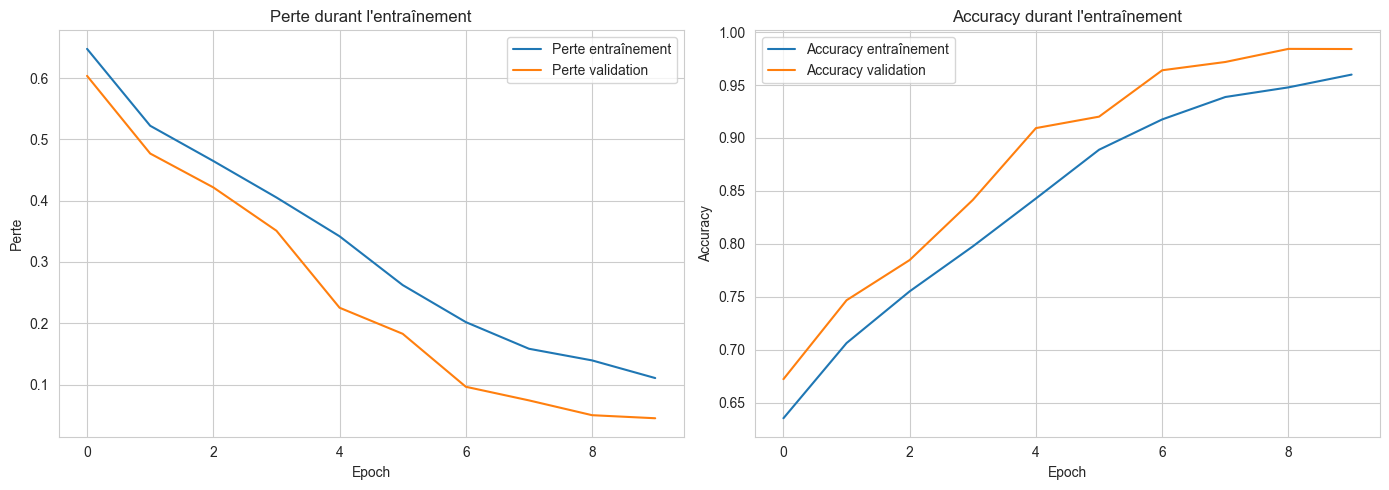

In [9]:
# Visualiser l'historique d'entraînement
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Perte
axes[0].plot(history.history['loss'], label='Perte entraînement')
axes[0].plot(history.history['val_loss'], label='Perte validation')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Perte')
axes[0].set_title('Perte durant l\'entraînement')
axes[0].legend()
axes[0].grid(True)

# Accuracy
axes[1].plot(history.history['accuracy'], label='Accuracy entraînement')
axes[1].plot(history.history['val_accuracy'], label='Accuracy validation')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy durant l\'entraînement')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

Évaluation du modèle sur l'ensemble de test...
220/220 [==============================] - 3s 10ms/step

MÉTRIQUES DE PERFORMANCE
Accuracy:  0.9841
Precision: 0.9841
Recall:    0.9841
F1-Score:  0.9841

Détail par classe:
                              precision    recall  f1-score   support

                       repos       0.98      0.98      0.98      2490
      environnement_immersif       0.98      0.97      0.98      2284
coherence_cardiaque_immersif       1.00      0.99      1.00      2253

                    accuracy                           0.98      7027
                   macro avg       0.98      0.98      0.98      7027
                weighted avg       0.98      0.98      0.98      7027



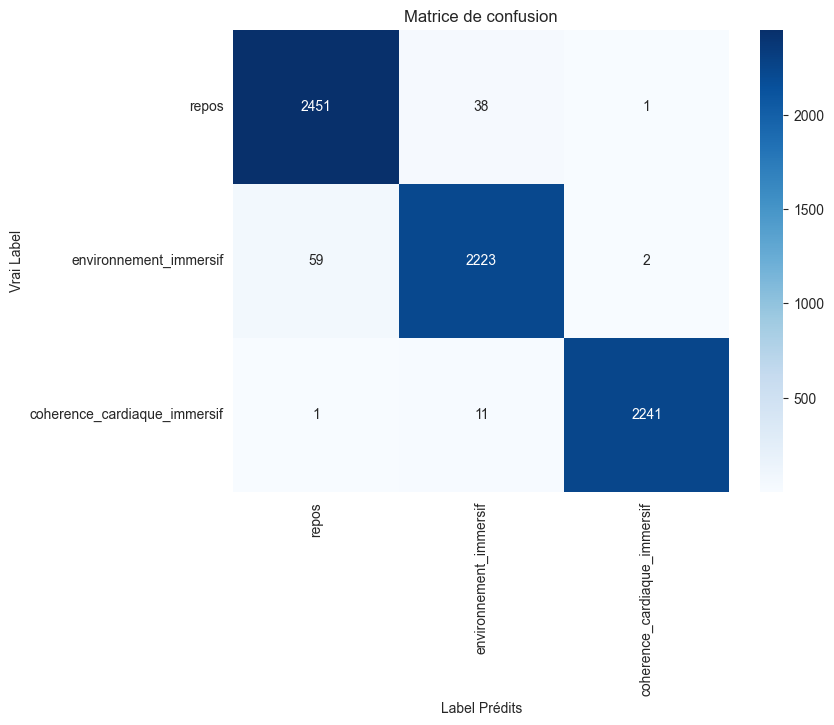

In [10]:
# Prédictions
print("Évaluation du modèle sur l'ensemble de test...")
y_pred_proba = model.predict(X_test)
y_pred = np.argmax(y_pred_proba, axis=1)

# Métriques
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print("\n" + "="*50)
print("MÉTRIQUES DE PERFORMANCE")
print("="*50)
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print("="*50)

if 'class_names' not in locals():
    class_names = [f'Class {i}' for i in range(NUM_CLASSES)]

# Classification Report
print("\nDétail par classe:")
print(classification_report(y_test, y_pred, target_names=class_names))

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True,
            xticklabels=class_names, yticklabels=class_names)
plt.title('Matrice de confusion')
plt.ylabel('Vrai Label')
plt.xlabel('Label Prédits')
plt.show()

## Influence de l'hyperparamètre SEQUENCE_LENGTH sur l'accuracy


=== SEQUENCE_LENGTH = 50 ===
Accuracy: 0.8792

=== SEQUENCE_LENGTH = 75 ===
Accuracy: 0.9664

=== SEQUENCE_LENGTH = 100 ===
Accuracy: 0.9576

=== SEQUENCE_LENGTH = 125 ===
Accuracy: 0.9932

=== SEQUENCE_LENGTH = 150 ===
Accuracy: 0.9969

=== SEQUENCE_LENGTH = 200 ===
Accuracy: 0.3097

=== SEQUENCE_LENGTH = 250 ===
Accuracy: 0.8548

Résumé influence SEQUENCE_LENGTH sur l'accuracy:
   sequence_length  accuracy
0               50  0.879180
1               75  0.966394
2              100  0.957626
3              125  0.993157
4              150  0.996918
5              200  0.309744
6              250  0.854821


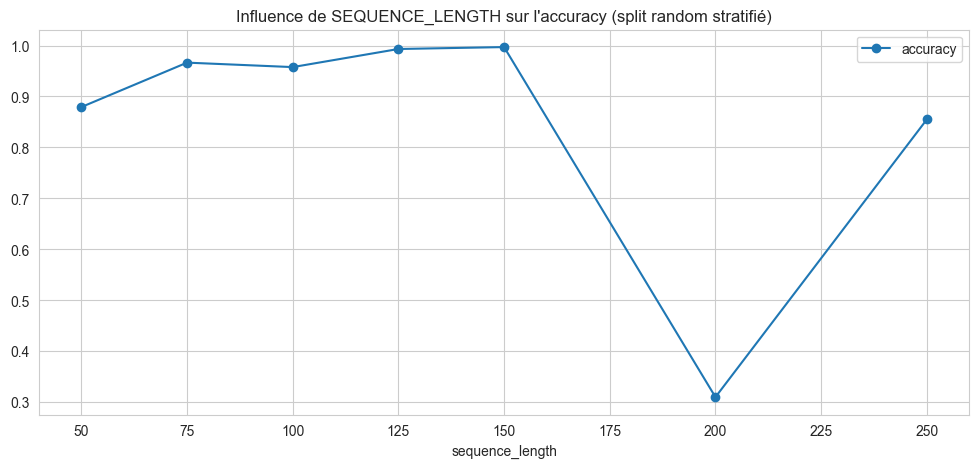

In [11]:
# Test de l'influence de SEQUENCE_LENGTH sur l'accuracy avec split random stratifié
sequence_lengths = [50, 75, 100, 125, 150, 200, 250]
results = []

for seq_len in sequence_lengths:
    print(f"\n=== SEQUENCE_LENGTH = {seq_len} ===")
    
    # Préparation des données avec la nouvelle longueur de séquence
    X_sequences = []
    y_labels = []
    source_info = []

    for col_idx, class_name in selected_columns.items():
        if col_idx >= rr_matrix.shape[1]:
            continue

        class_id = class_names.index(class_name)

        for row_idx in range(rr_matrix.shape[0]):
            cell_value = rr_matrix[row_idx, col_idx]
            series = np.asarray(cell_value).squeeze()

            if series.size == 0:
                continue

            try:
                series = np.asarray(series, dtype=float).reshape(-1)
            except (TypeError, ValueError):
                continue

            if len(series) < seq_len:
                continue

            scaler_local = StandardScaler()
            series_norm = scaler_local.fit_transform(series.reshape(-1, 1)).reshape(-1)

            for start in range(0, len(series_norm) - seq_len + 1):
                window = series_norm[start:start + seq_len]
                X_sequences.append(window)
                y_labels.append(class_id)
                source_info.append((row_idx, col_idx + 1, start))

    if len(X_sequences) == 0:
        print(f"Aucune séquence générée pour SEQUENCE_LENGTH={seq_len}")
        results.append({'sequence_length': seq_len, 'accuracy': None})
        continue

    X_seq = np.asarray(X_sequences, dtype=np.float32).reshape(-1, seq_len, 1)
    y_seq = np.asarray(y_labels, dtype=np.int32)

    if len(np.unique(y_seq)) < NUM_CLASSES:
        print(f"Classes insuffisantes pour SEQUENCE_LENGTH={seq_len}")
        results.append({'sequence_length': seq_len, 'accuracy': None})
        continue

    # Split random stratifié
    train_idx, test_idx = split_random_stratified(
        X_seq,
        y_seq,
        test_size=TEST_SIZE,
        random_state=42
    )

    X_train, X_test = X_seq[train_idx], X_seq[test_idx]
    y_train, y_test = y_seq[train_idx], y_seq[test_idx]
    y_train_encoded = tf_keras.utils.to_categorical(y_train, NUM_CLASSES)
    y_test_encoded = tf_keras.utils.to_categorical(y_test, NUM_CLASSES)

    # Nouveau modèle pour chaque test
    model = create_cnn_lstm_model(seq_len, NUM_FEATURES, NUM_CLASSES)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    # Class weights
    class_counts = np.bincount(y_train, minlength=NUM_CLASSES)
    class_weights = {
        i: float(len(y_train)) / (NUM_CLASSES * class_counts[i])
        for i in range(NUM_CLASSES)
        if class_counts[i] > 0
    }

    # Early stopping court pour accélérer le processus
    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=2,
        restore_best_weights=True,
        verbose=0
    )

    # Entraînement rapide pour tester l'influence de SEQUENCE_LENGTH
    history = model.fit(
        X_train, y_train_encoded,
        validation_data=(X_test, y_test_encoded),
        epochs=5,
        batch_size=BATCH_SIZE,
        callbacks=[early_stop],
        class_weight=class_weights,
        verbose=0
    )

    # Évaluation
    y_pred_proba = model.predict(X_test, verbose=0)
    y_pred = np.argmax(y_pred_proba, axis=1)
    acc = accuracy_score(y_test, y_pred)

    print(f"Accuracy: {acc:.4f}")
    results.append({'sequence_length': seq_len, 'accuracy': acc})

# Affichage des résultats
df_results = pd.DataFrame(results)
print("\nRésumé influence SEQUENCE_LENGTH sur l'accuracy:")
print(df_results)

df_results.plot(
    x='sequence_length',
    y='accuracy',
    marker='o',
    title="Influence de SEQUENCE_LENGTH sur l'accuracy (split random stratifié)"
)
plt.show()